<a href="https://colab.research.google.com/github/peterbabulik/QuantumWalker/blob/main/BabulikAsymmetryIndex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install cma

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 kB 1.8 MB/s eta 0:00:00


--- Measuring the Asymmetry of Existence ---

--- Evolving the Σ₂ Artist (Pure Creativity)... ---
--- Evolving the Π₂ Critic (Pure Logic)... ---

--- Calculating the Babulik Asymmetry Index (A_B) ---

--- QUANTITATIVE RESULTS ---
Volume of Imaginable Space (V_Sigma2): 100.0000
Volume of Provable Space (V_Pi2):    2.5131
Babulik Asymmetry Index (A_B):         0.9749

--- Visualizing the Asymmetry ---


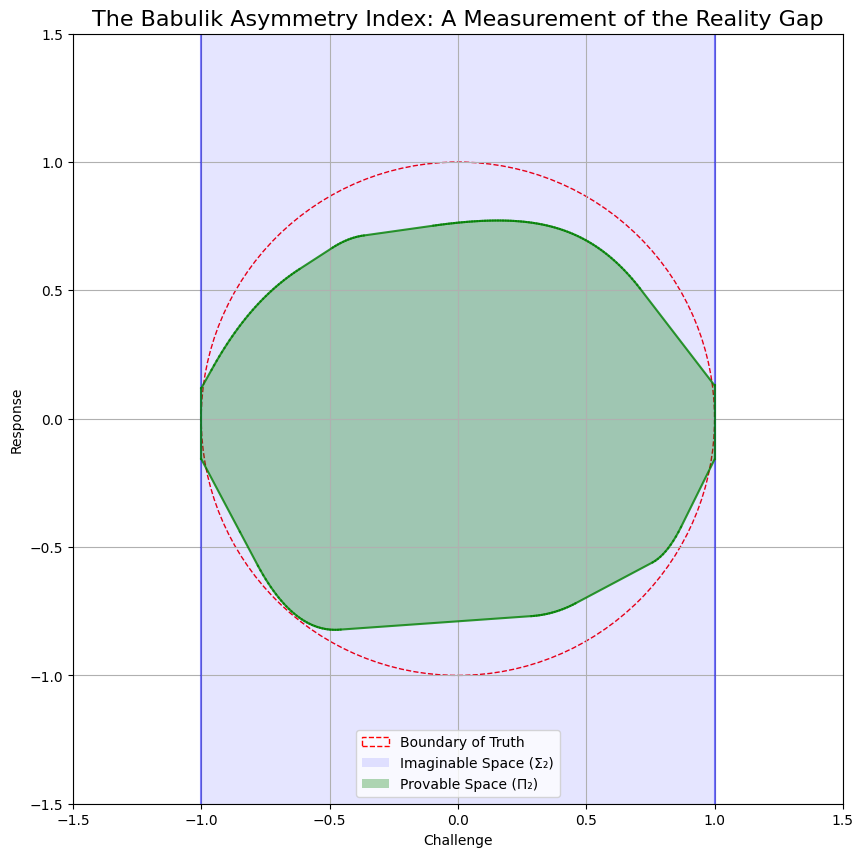

In [2]:

# ==============================================================================
#  The Final Experiment: Measuring the Babulik Asymmetry Index
#
#  Objective: To quantify the "Reality Gap" between the Creative Principle (Sigma-2)
#  and the Logical Principle (Pi-2) in a computational universe.
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
import cma
from scipy.spatial import ConvexHull
from matplotlib.patches import Ellipse

# ==============================================================================
#  The Universe and Solver (Unchanged)
# ==============================================================================
PROBLEM_PARAMS = {'a': 1.0, 'b': 1.0}
CHALLENGES = np.linspace(-1, 1, 200)

def is_response_valid(challenge_x, response_y, a, b):
    return (challenge_x / a)**2 + (response_y / b)**2 < 1.0

class Solver:
    def __init__(self, genes: np.ndarray):
        self.poly = np.poly1d(genes)
    def get_response(self, challenge_x: np.ndarray) -> np.ndarray:
        return self.poly(challenge_x)

# ==============================================================================
#  The Two Competing Fitness Functions (Artist vs. Critic)
# ==============================================================================
def sigma2_artist_fitness(genes: np.ndarray) -> float:
    solver = Solver(genes)
    responses = solver.get_response(CHALLENGES)
    radii = np.sqrt(CHALLENGES**2 + responses**2)
    return 1.0 - np.mean(radii)

def pi2_critic_fitness(genes: np.ndarray) -> float:
    solver = Solver(genes)
    responses = solver.get_response(CHALLENGES)
    validity_mask = is_response_valid(CHALLENGES, responses, 1.0, 1.0)
    num_failures = np.sum(~validity_mask)
    failure_cost = num_failures * 1000.0
    boldness_bonus = 1.0
    if num_failures == 0 and np.any(validity_mask):
        radii = np.sqrt(CHALLENGES[validity_mask]**2 + responses[validity_mask]**2)
        boldness_bonus = 1.0 - np.mean(radii)
    return failure_cost + boldness_bonus

# ==============================================================================
#  The Main Execution
# ==============================================================================
if __name__ == "__main__":
    NUM_GENES = 5
    options = {'bounds': [-5, 5], 'maxfevals': 10000, 'verbose': -9}
    NUM_RUNS = 20 # Run each AI multiple times to get a good sample of solutions

    print("--- Measuring the Asymmetry of Existence ---")

    # --- 1. Evolve the Artist Population ---
    print("\n--- Evolving the Σ₂ Artist (Pure Creativity)... ---")
    artist_solutions = []
    for _ in range(NUM_RUNS):
        es_artist = cma.CMAEvolutionStrategy(np.zeros(NUM_GENES), 0.5, options)
        es_artist.optimize(sigma2_artist_fitness)
        artist_solutions.append(es_artist.result.xbest)

    # --- 2. Evolve the Critic Population ---
    print("--- Evolving the Π₂ Critic (Pure Logic)... ---")
    critic_solutions = []
    for _ in range(NUM_RUNS):
        es_critic = cma.CMAEvolutionStrategy(np.zeros(NUM_GENES), 0.5, options)
        es_critic.optimize(pi2_critic_fitness)
        critic_solutions.append(es_critic.result.xbest)

    # --- 3. The Calculation of the Asymmetry Index ---
    print("\n--- Calculating the Babulik Asymmetry Index (A_B) ---")

    # Generate a dense cloud of points for the Artist's "Imaginable Space"
    artist_points = []
    for genes in artist_solutions:
        solver = Solver(genes)
        artist_points.extend(list(zip(CHALLENGES, solver.get_response(CHALLENGES))))
    artist_points = np.array(artist_points)

    # Generate a dense cloud of points for the Critic's "Provable Space"
    critic_points = []
    for genes in critic_solutions:
        solver = Solver(genes)
        critic_points.extend(list(zip(CHALLENGES, solver.get_response(CHALLENGES))))
    critic_points = np.array(critic_points)

    # Calculate the area of the convex hull for each space
    v_sigma2 = ConvexHull(artist_points).volume if len(artist_points) > 2 else 0
    v_pi2 = ConvexHull(critic_points).volume if len(critic_points) > 2 else 0

    # Calculate the Asymmetry Index
    if v_sigma2 > 0:
        asymmetry_index = (v_sigma2 - v_pi2) / v_sigma2
    else:
        asymmetry_index = 0 # No imaginable space, no asymmetry

    print("\n--- QUANTITATIVE RESULTS ---")
    print(f"Volume of Imaginable Space (V_Sigma2): {v_sigma2:.4f}")
    print(f"Volume of Provable Space (V_Pi2):    {v_pi2:.4f}")
    print(f"Babulik Asymmetry Index (A_B):         {asymmetry_index:.4f}")

    # --- 4. Visualization ---
    print("\n--- Visualizing the Asymmetry ---")
    fig, ax = plt.subplots(figsize=(10, 10))

    circle = plt.Circle((0, 0), 1, color='red', fill=False, linestyle='--', label='Boundary of Truth')
    ax.add_artist(circle)

    # Plot the convex hulls
    if v_sigma2 > 0:
        for simplex in ConvexHull(artist_points).simplices:
            ax.plot(artist_points[simplex, 0], artist_points[simplex, 1], 'b-', alpha=0.5)
        ax.fill(artist_points[ConvexHull(artist_points).vertices,0], artist_points[ConvexHull(artist_points).vertices,1], 'b', alpha=0.1, label='Imaginable Space (Σ₂)')

    if v_pi2 > 0:
        for simplex in ConvexHull(critic_points).simplices:
            ax.plot(critic_points[simplex, 0], critic_points[simplex, 1], 'g-', alpha=0.8)
        ax.fill(critic_points[ConvexHull(critic_points).vertices,0], critic_points[ConvexHull(critic_points).vertices,1], 'g', alpha=0.3, label='Provable Space (Π₂)')

    ax.set_title("The Babulik Asymmetry Index: A Measurement of the Reality Gap", fontsize=16)
    ax.set_xlabel("Challenge")
    ax.set_ylabel("Response")
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)
    ax.legend()
    plt.show()